In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import LabelEncoder
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
df = pd.read_csv("../input/spaceship-titanic/train.csv")

In [3]:
df.head()
df = df.drop(["PassengerId", "Name"], axis = 1)

In [4]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6764 entries, 0 to 8692
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    6764 non-null   object 
 1   CryoSleep     6764 non-null   object 
 2   Cabin         6764 non-null   object 
 3   Destination   6764 non-null   object 
 4   Age           6764 non-null   float64
 5   VIP           6764 non-null   object 
 6   RoomService   6764 non-null   float64
 7   FoodCourt     6764 non-null   float64
 8   ShoppingMall  6764 non-null   float64
 9   Spa           6764 non-null   float64
 10  VRDeck        6764 non-null   float64
 11  Transported   6764 non-null   bool   
dtypes: bool(1), float64(6), object(5)
memory usage: 640.7+ KB


In [6]:
le = LabelEncoder()
columns = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP",  "Transported"]
df[columns] = df[columns].apply(le.fit_transform)

In [7]:
df = df.iloc[:, 1:]
df

,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0,138,2,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,0,1854,2,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,0,1856,2,16.0,0,303.0,70.0,151.0,565.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...
8688,0,135,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0
8689,1,4381,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0
8690,0,4386,2,26.0,0,0.0,0.0,1872.0,1.0,0.0,1
8691,0,1809,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0


In [8]:
from sklearn.model_selection import train_test_split
labels = df["Transported"]
X_train, X_test, y_train, y_test = train_test_split(df.drop("Transported", axis = 1), labels, test_size = 0.20, random_state = 42)

In [9]:
X_train.head()

,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
1602,1,512,2,17.0,0,0.0,0.0,0.0,0.0,0.0
7439,0,1709,2,53.0,0,868.0,0.0,686.0,520.0,24.0
5720,0,2155,2,33.0,0,301.0,0.0,501.0,0.0,1013.0
7757,1,776,2,23.0,0,0.0,0.0,0.0,0.0,0.0
7946,1,1107,2,29.0,1,0.0,0.0,0.0,0.0,0.0


In [10]:
tf.random.set_seed(42)

In [11]:
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100, activation = "relu", input_shape = (1,10)),
    tf.keras.layers.Dense(100, activation = "relu"),
    tf.keras.layers.Dense(100, activation = "relu"),

    tf.keras.layers.Dense(1, activation = "sigmoid")
])

#callback_1 = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3*10**(epoch/20))

model_1.compile(loss = tf.keras.losses.BinaryCrossentropy(),
               optimizer = tf.keras.optimizers.Adam(0.001),
               metrics = ["accuracy"])

history = model_1.fit(X_train, y_train, epochs = 30, verbose = 2, validation_data = (X_test, y_test) )

2023-01-09 20:11:30.323404: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2023-01-09 20:11:30.570178: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/30
170/170 - 2s - loss: 7.4462 - accuracy: 0.6694 - val_loss: 2.9127 - val_accuracy: 0.7206
Epoch 2/30
170/170 - 0s - loss: 2.0146 - accuracy: 0.7171 - val_loss: 1.3521 - val_accuracy: 0.7857
Epoch 3/30
170/170 - 1s - loss: 2.2461 - accuracy: 0.7006 - val_loss: 1.1767 - val_accuracy: 0.7871
Epoch 4/30
170/170 - 0s - loss: 1.4099 - accuracy: 0.7191 - val_loss: 1.9136 - val_accuracy: 0.6423
Epoch 5/30
170/170 - 0s - loss: 1.3209 - accuracy: 0.7254 - val_loss: 0.8463 - val_accuracy: 0.7687
Epoch 6/30
170/170 - 0s - loss: 0.9294 - accuracy: 0.7366 - val_loss: 1.0215 - val_accuracy: 0.7524
Epoch 7/30
170/170 - 1s - loss: 0.7479 - accuracy: 0.7557 - val_loss: 0.9513 - val_accuracy: 0.6571
Epoch 8/30
170/170 - 1s - loss: 0.7708 - accuracy: 0.7433 - val_loss: 0.7075 - val_accuracy: 0.7849
Epoch 9/30
170/170 - 0s - loss: 0.6630 - accuracy: 0.7601 - val_loss: 0.6949 - val_accuracy: 0.7886
Epoch 10/30
170/170 - 1s - loss: 0.7299 - accuracy: 0.7485 - val_loss: 0.6735 - val_accuracy: 0.7908

In [12]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1, 100)            1100      
_________________________________________________________________
dense_1 (Dense)              (None, 1, 100)            10100     
_________________________________________________________________
dense_2 (Dense)              (None, 1, 100)            10100     
_________________________________________________________________
dense_3 (Dense)              (None, 1, 1)              101       
Total params: 21,401
Trainable params: 21,401
Non-trainable params: 0
_________________________________________________________________


In [13]:
X_test.shape

(1353, 10)

In [14]:
y_train.shape

(5411,)

In [15]:
y_test.shape

(1353,)

In [16]:
X_train.shape

(5411, 10)

In [17]:
y_test

7726    0
6296    1
3841    0
3003    0
636     0
       ..
7258    1
7524    1
8313    1
3436    0
1613    0
Name: Transported, Length: 1353, dtype: int64

<AxesSubplot:>

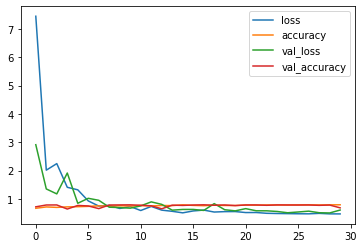

In [18]:
pd.DataFrame(history.history).plot()